# EDA Notebook
### 1st dataset
1. For this first dataset [https://www.kaggle.com/datasets/utsav15/it-helpdesk/data](https://www.kaggle.com/datasets/utsav15/it-helpdesk/data), we'll keep the title column and then do some nlp on resolution. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/it_clean_data.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Title,Resolution,class
0,0,0,Need Ethernet access,Please connect the LAN cable to the red port o...,41
1,1,1,Create new account and share the username and ...,"Go to URL : accountsetup.com, Enter personal d...",35
2,2,2,FW: Myspace Login Issue-- Ania,"Go to URL : password.reset.com, Enter you logi...",36
3,3,3,Login credetials are not working.,"Go to URL : password.reset.com, Enter you logi...",36
4,4,4,New Account is needed for a new joinee.,"Go to URL : accountsetup.com, Enter personal d...",35


In [2]:
# We're going to drop these columns as there was no documentation on what they were and they don't seem to be relevant to our analysis. 
df1 = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1','class'])

In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       59 non-null     object
 1   Resolution  59 non-null     object
dtypes: object(2)
memory usage: 1.1+ KB


In [4]:
df1[['Title','Resolution']].head()

,Title,Resolution
0,Need Ethernet access,Please connect the LAN cable to the red port o...
1,Create new account and share the username and ...,"Go to URL : accountsetup.com, Enter personal d..."
2,FW: Myspace Login Issue-- Ania,"Go to URL : password.reset.com, Enter you logi..."
3,Login credetials are not working.,"Go to URL : password.reset.com, Enter you logi..."
4,New Account is needed for a new joinee.,"Go to URL : accountsetup.com, Enter personal d..."


In [5]:
# getting the title, and checking for the most frequently used words.
# preprocess > remove punctuation, lowercase, remove stop words, lemmatize
# need to get the most commonly used keywords for classification
import re

all_title1 = ' '.join(df['Title'].astype(str))
all_title1 = all_title1.lower()
words = re.sub(r'[^\w\s]', '', all_title1)
print(len(words))
#print(words)

2364


In [8]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import string

#nltk.download('punkt')
#nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
tokens_no_stop = [word for word in word_tokenize(words) if word not in stop_words]
print(len(tokens_no_stop))
print(tokens_no_stop)

fdist = FreqDist(tokens_no_stop)
df1_most_common = fdist.most_common(20)
df1_most_common

233
['need', 'ethernet', 'access', 'create', 'new', 'account', 'share', 'username', 'password', 'fw', 'myspace', 'login', 'issue', 'ania', 'login', 'credetials', 'working', 'new', 'account', 'needed', 'new', 'joinee', 'request', 'configure', 'system', 'share', 'among', 'users', 'needs', 'permission', 'wifi', 'access', 'laptop', 'lan', 'working', 'vm', 'wifi', 'access', 'needed', 'space', 'qa', 'application', 'configure', 'outlook', 'system', 'install', 'postgres', 'database', 'machine', 'system', 'showing', 'blue', 'screen', 'startup', 'desktop', 'working', 'system', 'behaving', 'strangely', 'blue', 'screen', 'appearing', 'middle', 'internet', 'working', 'account', 'got', 'locked', '3', 'wrong', 'attempts', 'os', 'password', 'could', 'please', 'reset', 'password', 'system', 'hangs', 'blue', 'screen', 'startup', 'unable', 'connect', 'internet', 'facing', 'networkinternet', 'issue', 'wifi', 'xwq090', 'replace', 'battery', 'macbook', 'laptop', 'computer', 'getting', 'switched', 'forgot', 

[('computer', 9),
 ('password', 7),
 ('working', 5),
 ('system', 5),
 ('screen', 5),
 ('account', 4),
 ('virus', 4),
 ('windows', 4),
 ('access', 3),
 ('new', 3),
 ('login', 3),
 ('wifi', 3),
 ('install', 3),
 ('blue', 3),
 ('internet', 3),
 ('email', 3),
 ('drive', 3),
 ('cant', 3),
 ('printer', 3),
 ('share', 2)]

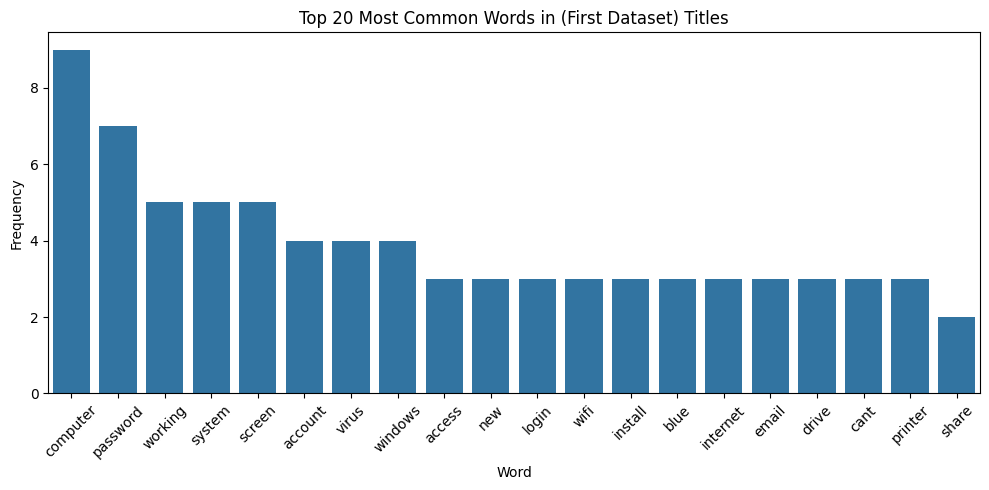

In [59]:
# Let's plot that
df1_most_common_df = pd.DataFrame(df1_most_common, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 5))
sns.barplot(x='Word', y='Frequency', data=df1_most_common_df)
plt.xticks(rotation=45)
plt.title('Top 20 Most Common Words in (First Dataset) Titles')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/df1_top_words.png')
plt.show()

In [29]:
# Check some of the phrases used in Title
df1[df1['Title'].str.contains('login', case=False, na=False)]

,Title,Resolution
2,FW: Myspace Login Issue-- Ania,"Go to URL : password.reset.com, Enter you logi..."
3,Login credetials are not working.,"Go to URL : password.reset.com, Enter you logi..."
26,Account locked. Not able to login,Unlocked the account and new password is sent ...


### 2nd dataset
1. Second dataset from [https://www.kaggle.com/datasets/utsav15/it-helpdesk/data](https://www.kaggle.com/datasets/utsav15/it-helpdesk/data), we'll clean and merge and see if the most frequent words are similar.

In [38]:
#!pip install openpyxl

In [50]:
it2 = pd.read_excel('data/SampleInput.xlsx')
it2.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,TicketNumber,Client,Staff,Source,Title,Resolution,HelpTopic,DataOn,DueDate,ClosedDate,ModifiedDate,KYC
1,T955496,User,ITSupport,Email,Need Ethernet access,Please connect the LAN cable to the red port o...,Network & Wireless,12/17/15 12:00 PM,NaN,12/17/15 01:02 PM,12/17/15 12:59 PM,YY
2,IT413956,User,ITSupport,Email,Need a LAN Cable,Please come to IT desk and collect.,Accessories,14-12-2017 12:06,NaN,15-12-2017 13:13,14-12-2017 12:42,N
3,IT413444,User,ITSupport,Email,Need a laptop Conector.,Please come to IT desk and collect.,Accessories,14-12-2017 12:06,NaN,15-12-2017 13:13,14-12-2017 13:44,N
4,IT413923,User,ITSupport,Email,Need a mouse,hello Raj Ganpur<br /><br />please come to It ...,Accessories,14-12-2017 12:06,NaN,15-12-2017 13:13,15-12-2017 12:15,N


In [51]:
it2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   399 non-null    object
 1   Unnamed: 1   399 non-null    object
 2   Unnamed: 2   399 non-null    object
 3   Unnamed: 3   399 non-null    object
 4   Unnamed: 4   274 non-null    object
 5   Unnamed: 5   399 non-null    object
 6   Unnamed: 6   399 non-null    object
 7   Unnamed: 7   399 non-null    object
 8   Unnamed: 8   1 non-null      object
 9   Unnamed: 9   399 non-null    object
 10  Unnamed: 10  399 non-null    object
 11  Unnamed: 11  395 non-null    object
dtypes: object(12)
memory usage: 37.5+ KB


In [52]:
# Lets subset this data to just the columns we need. 
it3  = it2[['Unnamed: 4','Unnamed: 5','Unnamed: 6']]
it3.head()


,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Title,Resolution,HelpTopic
1,Need Ethernet access,Please connect the LAN cable to the red port o...,Network & Wireless
2,Need a LAN Cable,Please come to IT desk and collect.,Accessories
3,Need a laptop Conector.,Please come to IT desk and collect.,Accessories
4,Need a mouse,hello Raj Ganpur<br /><br />please come to It ...,Accessories


In [53]:
# Let's rename the columns and reset the index. Then drop the first 2 columns.
it3.columns = it3.iloc[0]
it3 = it3.iloc[1:].reset_index(drop=True)
it3.info()
#it3 = it3.drop(columns=['Unnamed: 0.1','Unnamed: 0^','class'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       273 non-null    object
 1   Resolution  398 non-null    object
 2   HelpTopic   398 non-null    object
dtypes: object(3)
memory usage: 9.5+ KB


In [54]:
it3['HelpTopic'].value_counts()

HelpTopic
Access Requests                          243
Accessories                              128
Network & Wireless                         7
Hardware Issue                             3
Data Center Services /Report VM issue      2
Software Request                           2
Email Services                             2
Hardware                                   2
Network                                    2
VPN access                                 1
Jira Requests                              1
Data Center Services                       1
Data Center Services /VM Request           1
Newhire Accounts                           1
Password Reset                             1
Software Installation & Configuration      1
Name: count, dtype: int64

This second dataset is really unbalanced with the majority of the data classifying as 'Access Requests' or 'Accessories'. Interested in seeing a couple of these vectors with a 1 count.


In [55]:
it3[it3['HelpTopic'].str.contains('Data Center', case=False, na=False)]

,Title,Resolution,HelpTopic
132,Public IP Address for Coffee House project,IT Team has Assigned public IP to the host. IP...,Data Center Services
134,server#11 got hanged and needed a restart,IT Team has restarted the server and its acces...,Data Center Services /Report VM issue
143,Linux VM for Azuba project,IT Team has created VM as per your requirement...,Data Center Services /VM Request
166,My Space QA application is down,We regret for the inconvinience caused. The is...,Data Center Services /Report VM issue


In [56]:
# Let's merge our two datasets together and see if we can find any insights.
it_clean = pd.merge(df1, it3, on=['Title','Resolution'], how='outer')
it_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       305 non-null    object
 1   Resolution  430 non-null    object
 2   HelpTopic   398 non-null    object
dtypes: object(3)
memory usage: 10.2+ KB


In [57]:
# Check for certain text in the title and check for phrases
it_clean[it_clean['Title'].str.contains('login', case=False, na=False)].value_counts()

Title                                                               Resolution                                                                                       HelpTopic      
Account locked. Not able to login                                   Unlocked the account and new password is sent to your email id.                                  Access Requests    1
FW: Myspace Login Issue-- Ania                                      Go to URL : password.reset.com, Enter you login id, enter password received, reset the password  Access Requests    1
Login Page Down                                                     Login server was down. It is up now. Please check.                                               Access Requests    1
Login Page is not getting displayed                                 Login server was down. It is up now. Please check.                                               Access Requests    1
Login Page not opening                                              Login s

In [60]:
# Some ticket titles were more of ticket status updates, so we will remove those.
invalid_titles = ['Status Changed','Collaborators added by end user','Ticket Marked Overdue','Ticket Updated','Ticket Assigned to Sandeep Reddy Jakkidi','Ticket Assigned to Shijil Kumar Aynoli','Ticket Assigned to Pavan Kumar Thukuntla','Ticket Assigned to Shashi Kumar Raju Hasthi', 'Ticket Assigned to Kishore Babu Ganesana', 'Ticket Assigned to N V R S Surya Narayana Garlapati','New Collaborator Added', 'Ticket Assigned to Janardhana Rao Vemulapalli','Ticket Assigned to Nagaraju Mochi', 'Ticket Assigned to Vinod Kumar Reddy Dendi', 'New Ticket by Agent','Ticket Assigned to Anil Kumar Thanjavuru']
it_all_titles = it_clean[~it_clean['Title'].isin(invalid_titles)]
it_all_titles = ' '.join(it_all_titles['Title'].dropna().astype(str))
it_all_titles = it_all_titles.lower()
it_all_titles_clean = re.sub(r'[^\w\s]', '', it_all_titles)
print(len(it_all_titles_clean))

# Tokenize the titles and remove stop words.
tokens_no_stop2 = [word for word in word_tokenize(it_all_titles_clean) if word not in stop_words]
print(len(tokens_no_stop2))
print(tokens_no_stop2)

# Let's get frequency counts
fdist2 = FreqDist(tokens_no_stop2)
df2_most_common = fdist2.most_common(20)
df2_most_common

3728
403
['account', 'got', 'locked', '3', 'wrong', 'attempts', 'os', 'password', 'could', 'please', 'reset', 'password', 'account', 'locked', 'able', 'login', 'spaces', 'allowed', 'email', 'addresses', 'virus', 'damage', 'computer', 'hardware', 'computer', 'getting', 'switched', 'configure', 'outlook', 'system', 'create', 'new', 'account', 'share', 'username', 'password', 'creation', 'mail', 'id', 'new', 'joinee', 'desktop', 'working', 'windows', 'come', 'virus', 'protection', 'program', 'fw', 'myspace', 'login', 'issue', 'ania', 'facing', 'networkinternet', 'issue', 'wifi', 'xwq090', 'file', 'import', 'error', 'file', 'import', 'error', 'file', 'import', 'error', 'file', 'import', 'error', 'forgot', 'password', 'please', 'reset', 'password', 'clean', 'keyboard', 'recover', 'file', 'recycle', 'bin', 'update', 'microsoft', 'windows', 'computer', 'delete', 'internet', 'cookies', 'determine', 'computers', 'name', 'fix', 'paper', 'jam', 'get', 'safe', 'mode', 'map', 'network', 'drive', 'u

[('login', 9),
 ('computer', 9),
 ('password', 8),
 ('need', 8),
 ('install', 7),
 ('system', 6),
 ('working', 6),
 ('wifi', 6),
 ('file', 6),
 ('unable', 6),
 ('access', 6),
 ('internet', 5),
 ('needed', 5),
 ('screen', 5),
 ('account', 4),
 ('virus', 4),
 ('outlook', 4),
 ('new', 4),
 ('windows', 4),
 ('import', 4)]

In [ ]:
# Let's plot that
df2_most_common_df = pd.DataFrame(df2_most_common, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 5))
sns.barplot(x='Word', y='Frequency', data=df2_most_common_df)
plt.xticks(rotation=45)
plt.title('Top 20 Most Common Words in (Second Dataset) Titles')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/df2_top_words.png')
plt.show()

These values are simliar to the ones I have thought about.  I will align the final dataset to include the following issue types:
* Access Requests (include new hire and termination requests)
* Password Resets
* Accessories
* Hardware issue
* Software issue
* Security (malware detection, unauthorized access)
* Network
* Needs more information
* Service outage
* Misc (other) issues

In [ ]:
# The following dataset is also from Kaggle:
# https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets
# We will subset this dataset to include Engligh and 'IT Support' tickets 
csit = pd.read_csv('data/cs-it/aa_dataset-tickets-multi-lang-5-2-50-version.csv')

In [ ]:
csit.info()

In [ ]:
csit = csit[(csit['language'] == "en") & (csit['queue'] == "IT Support")]
#csit.head()
csit.info()

In [ ]:
# let's remove the tags that were used for auto tagging in the original dataset as they aren't relevant to our analysis.
# we'll also remove the other irrelevant fields and we already filtered out for english language and IT support queue.
csit_clean = csit.drop(columns=['tag_1','tag_2','tag_3','tag_4','tag_5','tag_6','tag_7','tag_8','queue','priority','language','type','version'])
csit_clean.dropna(inplace=True)
csit_clean.info()

In [ ]:
csit_clean.head()

In [ ]:
pd.set_option('display.max_colwidth', None)
csit_clean['subject']

In [ ]:
csit_all_titles = ' '.join(csit_clean['subject'].dropna().astype(str))
# remove punctuation
csit_all_titles_clean = re.sub(r'[^\w\s]', '', csit_all_titles)

# Tokenize the titles and remove stop words.
csit_tokens_no_stop = [word for word in word_tokenize(csit_all_titles_clean) if word not in stop_words]
print(len(csit_tokens_no_stop))
print(csit_tokens_no_stop)

# Let's get frequency counts
csit_fdist = FreqDist(csit_tokens_no_stop)
print(csit_fdist.most_common(20))

In [ ]:
# Check for certain text in the title and check for phrases
csit_clean[csit_clean['subject'].str.contains('windows', case=False, na=False)].value_counts()

I'm leaning more torwards taking a subset of the data that we can use.  The frequency counts don't appear to be simliar in this dataset. For now, we'l use the it_clean dataset and then add to it later. 

In [ ]:
it_clean = it_clean.rename(columns={'HelpTopic': 'Type'})
it_clean.info()


In [ ]:
# fill in missing values with 'Unknown'
it_clean['Title'] = it_clean['Title'].fillna('Unknown')
it_clean['Type'] = it_clean['Type'].fillna('Unknown')

# let's check the 'Type' values and recategorize them
it_clean['Type'].value_counts()
it_clean['Type'] = it_clean['Type'].replace({
    'Software Installation & Configuration': 'software',
    'Software Request': 'software',
    'Hardware Issue': 'hardware',
    'Network Issue': 'network',
    'Network & Wireless': 'network',
    'Access Issue': 'access request',
    'Access Request': 'access request',
    'VPN access': 'access request',
    'Newhire Accounts': 'access request',
    'Access Requests': 'access request',
    'Jira Requests': 'other',
    'Email Services': 'other',
    'Data Center Services /Report VM issue':'platform',
    'Data Center Services /VM Request':'platform',
    'Data Center Services':'platform',
})
it_clean.loc[it_clean['Title'].str.contains('password', case=False, na=False), 'Type'] = 'Password Reset'
it_clean['Type'].value_counts()

In [ ]:
# Let's manually inspect the unknown types and manualy reclassify them if possible.
it_clean[it_clean['Type'] == 'Unknown'][['Title','Type']]
#it_clean.loc[it_clean['Title'].str.contains('virus', case=False, na=False), 'Type'] = 'security'
#it_clean.loc[2, 'Type'] = 'Access'
it_clean.loc[56, 'Type'] = 'hardware'
it_clean.loc[59, 'Type'] = 'system'
it_clean.loc[61, 'Type'] = 'printer'
it_clean.loc[62, 'Type'] = 'system'
it_clean.loc[63, 'Type'] = 'system'
it_clean.loc[65, 'Type'] = 'system'
it_clean.loc[66, 'Type'] = 'system'
it_clean.loc[68, 'Type'] = 'system'
it_clean.loc[84, 'Type'] = 'system'
it_clean.loc[85, 'Type'] = 'system'
it_clean.loc[88, 'Type'] = 'system'
it_clean.loc[169, 'Type'] = 'hardware'
it_clean.loc[170, 'Type'] = 'system'
it_clean.loc[171, 'Type'] = 'system'
it_clean.loc[297, 'Type'] = 'system'
it_clean.loc[298, 'Type'] = 'system'
it_clean.loc[111, 'Type'] = 'system'
it_clean.loc[299, 'Type'] = 'system'
it_clean.loc[301, 'Type'] = 'system'
it_clean[it_clean['Type'] == 'Unknown'][['Title','Type']]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix 

X = it_clean['Title']
y = it_clean['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
    )),
    ('clf', LogisticRegression(max_iter=100, random_state=42))
])
pipeline.fit(X_train,y_train)

In [ ]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))